In [ ]:
%load_ext autoreload
%autoreload 2


from src.data.preprocessing import Preprocessing
from sklearn.preprocessing import StandardScaler

SEED = 42

train = Preprocessing('data/raw/train.csv')
path = 'data/train_expanded_df.csv'
train.load_expanded_df(path)

test= Preprocessing('data/raw/test.csv', is_train=False)
path = 'data/test_expanded_df.csv'
test.load_expanded_df(path)


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train.expanded_df['language'] = label_encoder.fit_transform(train.expanded_df['language'])

normalize_cols=['language','sentence','pagerank', 'betweenness', 'harmonic', 'degree', 'closeness','katz','eccentricity', 'avg_distance','branching_factor','tree_vitality','depth', 'depth_ratio','neighbor_degree','structural_holes']
feature_columns=['norm_language','norm_sentence','pagerank', 'betweenness', 'harmonic', 'degree', 'closeness','katz','eccentricity', 'avg_distance','branching_factor','tree_vitality','depth', 'depth_ratio','neighbor_degree','structural_holes']
scaler = StandardScaler()
train.expanded_df[feature_columns]= scaler.fit_transform(train.expanded_df[normalize_cols])


#test.expanded_df['language'] = label_encoder.fit_transform(test.expanded_df['language'])
#test.expanded_df[normalize_cols]= scaler.fit_transform(test.expanded_df[normalize_cols])



In [25]:
print(train.expanded_df)

           id  language  sentence  node  is_root  pagerank  betweenness  \
0           1        12         2     6        0 -0.126200    -0.442820   
1           1        12         2     4        0 -0.712759    -0.860361   
2           1        12         2     2        0  0.376293     0.312731   
3           1        12         2    23        0 -0.758911    -0.860361   
4           1        12         2    20        0 -0.290991     0.571209   
...       ...       ...       ...   ...      ...       ...          ...   
197474  10500        16       995    19        0 -0.576138    -0.860361   
197475  10500        16       995     1        0 -0.642112    -0.860361   
197476  10500        16       995    14        0 -0.642112    -0.860361   
197477  10500        16       995     5        0  0.106725    -0.350033   
197478  10500        16       995    16        0 -0.576138    -0.860361   

        harmonic    degree  closeness  ...  norm_language  norm_sentence  \
0      -0.372756 -0.196

In [ ]:
import numpy as np
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
import torch


node_features= torch.tensor(train.expanded_df.loc[:, ~train.expanded_df.columns.isin(['id','node','is_root'])].values, dtype=torch.float32)


edge_index = np.array(train.edges).T
edge_index = torch.tensor(edge_index, dtype=torch.long)
edge_index = to_undirected(edge_index)


# Create dataset object
data = Data(x=node_features, edge_index=edge_index)
print(data)

import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATConv(data.num_node_features, 32)
        self.conv2 = GATConv(32, 8)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return x
    
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GAT().to(device)
data = data.to(device)

embeddings = model(data)

gnn_embeddings = embeddings.detach().numpy()
for dim in range(gnn_embeddings.shape[1]):
    train.expanded_df[f'gnn_emb_{dim}'] = gnn_embeddings[:, dim]

Data(x=[197479, 18], edge_index=[2, 373958])


In [31]:
from sklearn.model_selection import train_test_split
# Let's assume 'nodes' is your DataFrame and 'label' is your target column
feature_columns=['norm_language','norm_sentence','pagerank', 'betweenness', 'harmonic', 'closeness','katz','eccentricity', 'avg_distance','depth_ratio','neighbor_degree','structural_holes','gnn_emb_0','gnn_emb_1','gnn_emb_2','gnn_emb_3','gnn_emb_4','gnn_emb_5','gnn_emb_6','gnn_emb_7' ]
# 2. Create query IDs for proper splitting
query_ids = train.expanded_df['id'].values

# 3. Split at query level (keep all items from same query together)
unique_qids = np.unique(query_ids)
train_qids, test_qids = train_test_split(unique_qids, test_size=0.2, random_state=42)

X_train = train.expanded_df.loc[train.expanded_df['id'].isin(train_qids)].sort_values(by=['language', 'sentence'])
X_test = train.expanded_df.loc[train.expanded_df['id'].isin(test_qids)].sort_values(by=['language', 'sentence'])

train_groups=X_train.groupby(['language', 'sentence']).size().values
test_groups=X_test.groupby(['language', 'sentence']).size().values

X_train = X_train[feature_columns].values 
X_test = X_test[feature_columns].values 
y_train = train.expanded_df.loc[train.expanded_df['id'].isin(train_qids)]['is_root'].values 
y_test = train.expanded_df.loc[train.expanded_df['id'].isin(test_qids)]['is_root'].values 

In [40]:
import xgboost
print(xgboost.__version__)

3.0.0


In [52]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from xgboost.callback import EarlyStopping

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Step 1: Resample
smote = SMOTE(sampling_strategy=0.1, random_state=SEED)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Step 2: Split resampled into train/val for early stopping
X_res_train, X_res_val, y_res_train, y_res_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=SEED
)

# Step 3: Train XGBoost with early stopping
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=SEED,
    n_estimators=1000,
    learning_rate=0.05
)

xgb_model.fit(
    X_res_train,
    y_res_train,
    eval_set=[(X_res_val, y_res_val)],
    verbose=False
)

# Step 4: Train LightGBM with early stopping
lgbm_model = LGBMClassifier(
    random_state=SEED,
    n_estimators=1000,
    learning_rate=0.05
)

lgbm_model.fit(
    X_res_train,
    y_res_train,
    eval_set=[(X_res_val, y_res_val)],
    callbacks=[lgb.early_stopping(50)]
)



print("XGBoost Model Performance")
# --- Predict on original training data ---
train_preds = xgb_model.predict(X_train)
train_probs = xgb_model.predict_proba(X_train)[:, 1]

print("📊 TRAINING PERFORMANCE:")
print(classification_report(y_train, train_preds))
print("\nAUC:", roc_auc_score(y_train, train_probs))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds))
print("="*60)

# --- Predict on test set ---
test_preds = xgb_model.predict(X_test)
test_probs = xgb_model.predict_proba(X_test)[:, 1]

print("📊 TEST PERFORMANCE:")
print(classification_report(y_test, test_preds))
print("\nAUC:", roc_auc_score(y_test, test_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_preds))


print("LightGBM Model Performance")

# --- Predict on original training data ---
train_preds = lgbm_model.predict(X_train)
train_probs = lgbm_model.predict_proba(X_train)[:, 1]

print("📊 TRAINING PERFORMANCE:")
print(classification_report(y_train, train_preds))
print("\nAUC:", roc_auc_score(y_train, train_probs))
print("Confusion Matrix:\n", confusion_matrix(y_train, train_preds))
print("="*60)

# --- Predict on test set ---
test_preds = lgbm_model.predict(X_test)
test_probs = lgbm_model.predict_proba(X_test)[:, 1]

print("📊 TEST PERFORMANCE:")
print(classification_report(y_test, test_preds))
print("\nAUC:", roc_auc_score(y_test, test_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_preds))


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[440]	valid_0's binary_logloss: 0.207594
XGBoost Model Performance
📊 TRAINING PERFORMANCE:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    149667
           1       0.96      0.01      0.02      8400

    accuracy                           0.95    158067
   macro avg       0.95      0.51      0.50    158067
weighted avg       0.95      0.95      0.92    158067


AUC: 0.8198857431752459
Confusion Matrix:
 [[149663      4]
 [  8315     85]]
📊 TEST PERFORMANCE:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     37312
           1       0.00      0.00      0.00      2100

    accuracy                           0.95     39412
   macro avg       0.47      0.50      0.49     39412
weighted avg       0.90      0.95      0.92     39412


AUC: 0.508195875959732
Confusion Matrix:
 [[37309     3]
 [

In [ ]:
import lightgbm as lgb
import numpy as np
import xgboost as xgb  
from xgboost.callback import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ndcg_score
from lightgbm import LGBMRanker
from xgboost import XGBRanker
from catboost import CatBoostRanker, Pool
from sklearn.ensemble import RandomForestRegressor

feature_columns=['norm_language','norm_sentence','pagerank', 'betweenness', 'harmonic', 'closeness','katz','eccentricity', 'avg_distance','depth_ratio','neighbor_degree','structural_holes','gnn_emb_0','gnn_emb_1','gnn_emb_2','gnn_emb_3','gnn_emb_4','gnn_emb_5','gnn_emb_6','gnn_emb_7' ]
# 2. Create query IDs for proper splitting
query_ids = train.expanded_df['id'].values

# 3. Split at query level (keep all items from same query together)
unique_qids = np.unique(query_ids)
train_qids, test_qids = train_test_split(unique_qids, test_size=0.2, random_state=42)

X_train = train.expanded_df.loc[train.expanded_df['id'].isin(train_qids)].sort_values(by=['language', 'sentence'])
X_test = train.expanded_df.loc[train.expanded_df['id'].isin(test_qids)].sort_values(by=['language', 'sentence'])

train_groups=X_train.groupby(['language', 'sentence']).size().values
test_groups=X_test.groupby(['language', 'sentence']).size().values

X_train = X_train[feature_columns].values 
X_test = X_test[feature_columns].values 
y_train = train.expanded_df.loc[train.expanded_df['id'].isin(train_qids)]['is_root'].values 
y_test = train.expanded_df.loc[train.expanded_df['id'].isin(test_qids)]['is_root'].values 


# 4. Initialize models with better parameters
lgb_model = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    lambdarank_truncation_level=max(train_groups),
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=1000,
    random_state=42
)

xgb_model = XGBRanker(
    objective="rank:pairwise",
    eval_metric="ndcg@5",
    eta=0.05,
    max_depth=6,
    n_estimators=1000,
    random_state=42
)

cat_model = CatBoostRanker(
    loss_function="YetiRank",
    eval_metric="NDCG",
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

# 5. Train models with proper group handling
# LightGBM
lgb_model.fit(X_train, y_train, group=train_groups,
              eval_set=[(X_test, y_test)],
              eval_group=[test_groups],
              callbacks=[lgb.early_stopping(50)])

# XGBoost
xgb_model.fit(X_train, y_train, group=train_groups,
              eval_set=[(X_test, y_test)],
              eval_group=[test_groups])

# CatBoost needs Pool format
train_pool = Pool(X_train, y_train, group_id=np.repeat(range(len(train_groups)), train_groups))
test_pool = Pool(X_test, y_test, group_id=np.repeat(range(len(test_groups)), test_groups))

cat_model.fit(train_pool, eval_set=test_pool)

# 6. Generate predictions
lgb_preds = lgb_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)
cat_preds = cat_model.predict(test_pool)

# 7. Create ensemble
blended_test = np.column_stack([lgb_preds, xgb_preds, cat_preds])

# Use RandomForest as blender
blender = RandomForestRegressor(n_estimators=100, random_state=42)
blender.fit(np.column_stack([lgb_model.predict(X_train),
                           xgb_model.predict(X_train),
                           cat_model.predict(train_pool)]), 
           y_train)

ensemble_preds = blender.predict(blended_test)

# 8. Evaluation functions
def evaluate_ranking(y_true, pred_scores, groups):
    """Calculate NDCG for ranking"""
    ndcgs = []
    pos = 0
    for size in groups:
        if size > 1:  # NDCG requires at least 2 items
            true = y_true[pos:pos+size]
            pred = pred_scores[pos:pos+size]
            ndcgs.append(ndcg_score([true], [pred], k=min(5, size)))
        pos += size
    return np.mean(ndcgs)

def get_binary_preds(pred_scores, groups):
    """Convert scores to binary predictions (1 for top in group)"""
    binary_preds = []
    pos = 0
    for size in groups:
        if size > 0:
            result = np.zeros(size)
            result[np.argmax(pred_scores[pos:pos+size])] = 1
            binary_preds.extend(result)
        pos += size
    return np.array(binary_preds)

# 9. Evaluate all models
def evaluate_model(name, pred_scores, y_true, groups):
    binary_preds = get_binary_preds(pred_scores, groups)
    print(f"\n📊 {name.upper()} PERFORMANCE:")
    print("Classification Report:")
    print(classification_report(y_true, binary_preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, binary_preds))
    print(f"NDCG@5: {evaluate_ranking(y_true, pred_scores, groups):.4f}")
    print("="*60)

# Evaluate individual models
evaluate_model("LightGBM", lgb_preds, y_test, test_groups)
evaluate_model("XGBoost", xgb_preds, y_test, test_groups)
evaluate_model("CatBoost", cat_preds, y_test, test_groups)
evaluate_model("Ensemble", ensemble_preds, y_test, test_groups)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid_0's ndcg@1: 0.314762	valid_0's ndcg@2: 0.337672	valid_0's ndcg@3: 0.362256	valid_0's ndcg@4: 0.383649	valid_0's ndcg@5: 0.399043
0:	test: 0.4588145	best: 0.4588145 (0)	total: 154ms	remaining: 2m 33s
100:	test: 0.5370282	best: 0.5386826 (34)	total: 16.8s	remaining: 2m 29s


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

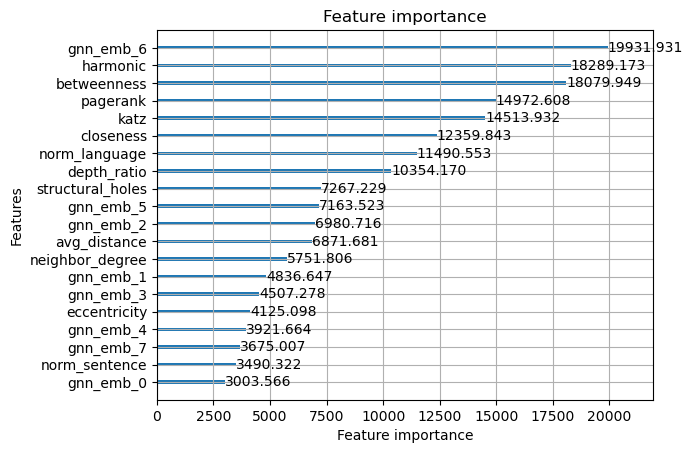

In [28]:
lgb.plot_importance(model, importance_type='gain', max_num_features=20)

In [67]:
import optuna
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


def objective(trial):
    # Sample SMOTE and CV values
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.1, 0.5)
    cv_folds = trial.suggest_int('cv', 3, 5)

    # Resample data
    smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Define base models
    lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
    xgb_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)

    # Define stacking model
    stacked_model = StackingClassifier(
        estimators=[('xgb', xgb_model), ('lgbm', lgbm_model)],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=cv_folds,
        n_jobs=-1,
        passthrough=True
    )

    stacked_model.fit(X_train_res, y_train_res)
    test_preds = stacked_model.predict(X_eval)
    macro_f1 = f1_score(y_eval, test_preds, average='macro')
    
    return macro_f1

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Best trial results
print("🔧 Best parameters:", study.best_params)
print("📈 Best F1:", study.best_value)


[I 2025-04-15 16:56:25,567] A new study created in memory with name: no-name-e70820e5-1de4-4589-908d-6501878e92c5
[I 2025-04-15 16:56:33,818] Trial 0 finished with value: 0.5728452272092256 and parameters: {'sampling_strategy': 0.13442168186596512, 'cv': 3}. Best is trial 0 with value: 0.5728452272092256.
[I 2025-04-15 16:56:41,958] Trial 1 finished with value: 0.6144005768041121 and parameters: {'sampling_strategy': 0.21547835958542105, 'cv': 3}. Best is trial 1 with value: 0.6144005768041121.
[I 2025-04-15 16:56:52,873] Trial 2 finished with value: 0.6090116322405219 and parameters: {'sampling_strategy': 0.35296393239699164, 'cv': 4}. Best is trial 1 with value: 0.6144005768041121.
[I 2025-04-15 16:57:02,912] Trial 3 finished with value: 0.5755221228511244 and parameters: {'sampling_strategy': 0.11564445036366183, 'cv': 4}. Best is trial 1 with value: 0.6144005768041121.
[I 2025-04-15 16:57:15,776] Trial 4 finished with value: 0.5772810584749972 and parameters: {'sampling_strategy': 

🔧 Best parameters: {'sampling_strategy': 0.24394022820708505, 'cv': 3}
📈 Best AUC: 0.6148266773972277


In [76]:
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

X_train = train.expanded_df[feature_columns]  # Use your selected features
y_train = train.expanded_df['is_root']  

# --- SMOTE resampling ---
smote = SMOTE(sampling_strategy=0.1, random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# --- Define base models ---
lgbm_model = LGBMClassifier(random_state=42, verbose=-1)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# --- Stacking model ---
stacked_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,  # you can increase for more stable results
    n_jobs=-1,
    passthrough=True  # optional: give meta-learner access to original features too
)

# --- Train the stacked model ---
stacked_model.fit(X_train_res, y_train_res)

# --- Predict on test set ---
preds = stacked_model.predict(X_train)
probs = stacked_model.predict_proba(X_train)[:, 1]


# --- Evaluation ---
print("📊 STACKED MODEL TEST PERFORMANCE:")
print(classification_report(y_train, preds))
print("\nAUC:", roc_auc_score(y_train, probs))
print("Confusion Matrix:\n", confusion_matrix(y_train, preds))


📊 STACKED MODEL TEST PERFORMANCE:
              precision    recall  f1-score   support

           0       0.99      0.50      0.67    186979
           1       0.09      0.90      0.17     10500

    accuracy                           0.52    197479
   macro avg       0.54      0.70      0.42    197479
weighted avg       0.94      0.52      0.64    197479


AUC: 0.7630085392833776
Confusion Matrix:
 [[94078 92901]
 [ 1003  9497]]


In [82]:
results = stacked_model.predict(X_test)
file="submission"
test.export_submission(results, file)